# **ECE2112_PA4**

**Jeremy Rafael G. Lacuna | 2ECE-C**

*This repository contains three programming problems which covers **Module 4 - Data Wrangling and Visualization**.*

**Objectives:**

1. Filter tabular data using several categorical and numerical conditions;
2. Construct focused DataFrames by selecting relevant features;
3. Summarize the relationship between categorical features and a numerical variable; and
4. Communicate a data comparison using clear and correctly labeled plots.

## **A. Visayas Communication Dataframe**

Create a DataFrame named `VisComm` containing students whose **Hometown** is **Visayas** and whose **Track** is **Communication**. Retain only these columns, in the stated order:

`Name, Gender, Math, Electronics, Average` <br>

Display the resulting DataFrame and its number of rows. Both filtering conditions must be applied to the source dataset before the columns are selected.

Functions used for this problem:
- **pd.read_excel()**: Used to **load the Excel file (.xlsx) into a Pandas DataFrame**.
- **.mean(axis=1)**: **Calculates the mean across the subject columns** in order to create an **Average** column.
- **len()**: Returns the **number of rows** in the DataFrame.

### **Code:**

In [57]:
import pandas as pd

def vis_communication():
    board2 = pd.read_excel('board2.xlsx')
    board2['Average'] = board2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

    VisComm = board2[(board2['Hometown'] == 'Visayas') & (board2['Track'] == 'Communication')][['Name', 'Gender', 'Math', 'Electronics', 'Average']]
    
    return VisComm, len(VisComm)

#### **Test Cases:**

In [58]:
VisComm, row_count = vis_communication()

In [59]:
print("VisComm DataFrame:\n", VisComm)

VisComm DataFrame:
    Name  Gender  Math  Electronics  Average
10  S11  Female    48           56    54.75
11  S12    Male    89           67    76.00
17  S18    Male    81           40    63.50
21  S22  Female    64           39    62.50
27  S28    Male    85           53    67.75


In [60]:
print("\nNumber of rows in VisComm:", row_count)


Number of rows in VisComm: 5


## **B. Visayas Female Dataframe**

Create a second DataFrame named `VisFemale` containing students whose **Hometown** is **Visayas** and whose **Gender** is **Female**. Retain only:

`Name, Track, GEAS, Electronics, Average` <br>

Display **VisFemale**. Then display only the rows of **VisFemale** whose **Average** is at least 60. Do not overwrite **VisFemale** when performing this second filter.

Functions used for this problem:
- **Conditional Filtering**: **Filters** the rows that meet the **score requirement** without modifying the DataFrame

### **Code:**

In [75]:
def vis_female():
    board2 = pd.read_excel('board2.xlsx')
    board2['Average'] = board2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

    VisFemale = board2[(board2['Hometown'] == 'Visayas') & (board2['Gender'] == 'Female')][['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
    
    filtered_VisFemale = VisFemale[VisFemale['Average'] >= 60]

    return VisFemale, filtered_VisFemale

#### **Test Cases:**

In [76]:
VisFemale, filtered_VisFemale = vis_female()

In [77]:
print("VisFemale DataFrame:\n", VisFemale)

VisFemale DataFrame:
    Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
10  S11     Communication    48           56    54.75
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
23  S24  Microelectronics    60           45    57.75
25  S26   Instrumentation    83           47    65.75


## **C. Category-Average Visualization**

Examine how the recorded Average differs across the three categorical features Track, Gender, and Hometown. <br>

a. For each feature, compute the mean of Average for every category using Pandas. <br>
b. Display the three summary tables. <br>
c. Create one figure containing three bar charts: mean Average by Track, by Gender, and by Hometown. <br>
d. Below the figure, write three concise statements identifying the category with the highest sample mean for each feature. <br>

**Interpretation rule:** Describe the observed dataset only. A difference in group means does not, by itself, establish that a feature causes a higher board-exam score.

Functions used for this problem:
- **.groupby()**: **Groups DataFrame rows by category**.
- **.mean()**: **Calculates the mean score** for each category.
- **plt.subplots()**: **Generates a grid of subplots.**
- **axes.bar()**: **Plots vertical bar charts.**
- **.idxmax()**: **Identifies the row index that corresponds to the maximum value.**

### **Code:**

In [78]:
import matplotlib.pyplot as plt

def category_average_visualization():
    board2 = pd.read_excel('board2.xlsx')
    board2['Average'] = board2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

    track_mean = board2.groupby('Track')['Average'].mean().reset_index()
    gender_mean = board2.groupby('Gender')['Average'].mean().reset_index()
    hometown_mean = board2.groupby('Hometown')['Average'].mean().reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    axes[0].bar(track_mean['Track'], track_mean['Average'], color='skyblue', edgecolor='black')
    axes[0].set_title('Mean Average by Track')
    axes[0].set_xlabel('Track')
    axes[0].set_ylabel('Mean Average Score')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(gender_mean['Gender'], gender_mean['Average'], color='lightgreen', edgecolor='black')
    axes[1].set_title('Mean Average by Gender')
    axes[1].set_xlabel('Gender')

    axes[2].bar(hometown_mean['Hometown'], hometown_mean['Average'], color='salmon', edgecolor='black')
    axes[2].set_title('Mean Average by Hometown')
    axes[2].set_xlabel('Hometown')

    plt.tight_layout()
    plt.show()

    top_track = track_mean.loc[track_mean['Average'].idxmax()]
    top_gender = gender_mean.loc[gender_mean['Average'].idxmax()]
    top_hometown = hometown_mean.loc[hometown_mean['Average'].idxmax()]

    statement_track = f"1. Track: The {top_track['Track']} track recorded the highest sample mean Average score ({top_track['Average']:.2f})."
    statement_gender = f"2. Gender: {top_gender['Gender']} students recorded the highest sample mean Average score ({top_gender['Average']:.2f})."
    statement_hometown = f"3. Hometown: Students from {top_hometown['Hometown']} recorded the highest sample mean Average score ({top_hometown['Average']:.2f})."

    return track_mean, gender_mean, hometown_mean, (statement_track, statement_gender, statement_hometown)

#### **Test Cases:**

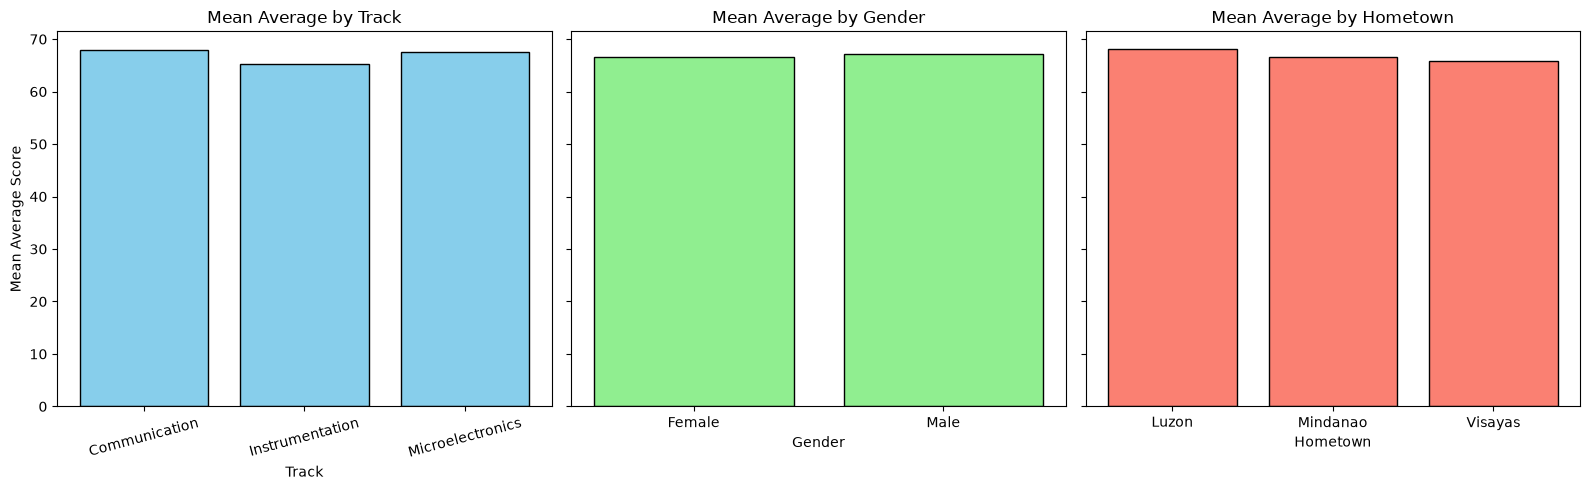

In [79]:
track_mean, gender_mean, hometown_mean, statements = category_average_visualization()

In [80]:
print("Track Mean:\n", track_mean)

Track Mean:
               Track  Average
0     Communication   67.975
1   Instrumentation   65.225
2  Microelectronics   67.500


In [81]:
print("\nGender Mean:\n", gender_mean)


Gender Mean:
    Gender    Average
0  Female  66.616667
1    Male  67.183333


In [82]:
print("\nHometown Mean:\n", hometown_mean)


Hometown Mean:
    Hometown    Average
0     Luzon  68.083333
1  Mindanao  66.678571
2   Visayas  65.750000


In [83]:
for statement in statements:
    print(statement)

1. Track: The Communication track recorded the highest sample mean Average score (67.97).
2. Gender: Male students recorded the highest sample mean Average score (67.18).
3. Hometown: Students from Luzon recorded the highest sample mean Average score (68.08).
